<a href="https://colab.research.google.com/github/anshmathur19/Crowd-Anomaly/blob/main/Copy_of_CAD_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import files
files.upload()

KeyboardInterrupt: 

In [ ]:
video_path = "UMN Dataset.mp4"
output_folder = "umn_frames"

os.makedirs(output_folder, exist_ok=True)

cap = cv2.VideoCapture(video_path)

count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (128,128))
    cv2.imwrite(f"{output_folder}/frame_{count}.jpg", frame)

    count += 1

cap.release()

print("Total frames:", count)

Total frames: 7739


In [ ]:
import os
files = sorted(os.listdir("umn_frames"),
               key=lambda x: int(x.split('_')[1].split('.')[0]))

SEQ_LENGTH = 10

sequences = []
labels = []

for i in range(len(files) - SEQ_LENGTH):

    seq_files = files[i:i+SEQ_LENGTH]

    if len(seq_files) == SEQ_LENGTH:
        sequences.append(seq_files)
        label = 0 if (i + SEQ_LENGTH) < int(len(files) * 0.7) else 1
        labels.append(label)

In [ ]:
from sklearn.model_selection import train_test_split

train_seq, val_seq, train_labels, val_labels = train_test_split(
    sequences, labels,
    test_size=0.3,
    shuffle=True,
    random_state=42
)

In [ ]:
def generator(seq_list, label_list, batch_size=8):

    while True:

        X_batch = []
        y_batch = []

        for idx in range(len(seq_list)):

            seq_files = seq_list[idx]
            label = label_list[idx]

            frames = []

            for file in seq_files:
                img = cv2.imread(os.path.join("umn_frames", file))

                if img is None:
                    continue

                img = cv2.resize(img, (128,128))
                img = img / 255.0
                frames.append(img)

            if len(frames) != len(seq_files):
                continue

            X_batch.append(frames)
            y_batch.append(label)

            if len(X_batch) == batch_size:
                yield np.array(X_batch), np.array(y_batch)
                X_batch, y_batch = [], []

        if len(X_batch) > 0:
            yield np.array(X_batch), np.array(y_batch)

In [ ]:
print("Train sequences:", len(train_seq))
print("Val sequences:", len(val_seq))

Train sequences: 5410
Val sequences: 2319


In [ ]:
train_gen = generator(train_seq, train_labels)
val_gen = generator(val_seq, val_labels)

In [ ]:
import tensorflow as tf
tf.keras.backend.clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import TimeDistributed
from tensorflow.keras.layers import Flatten, LSTM, Dense, Dropout

model = Sequential()

model.add(TimeDistributed(
    Conv2D(32,(3,3),activation='relu'),
    input_shape=(SEQ_LENGTH,128,128,3)
))

model.add(TimeDistributed(MaxPooling2D((2,2))))

model.add(TimeDistributed(
    Conv2D(64,(3,3),activation='relu')
))

model.add(TimeDistributed(MaxPooling2D((2,2))))

model.add(TimeDistributed(Flatten()))

model.add(LSTM(128))

model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 10, 126, 126,   │           896 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 63, 63, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 61, 61, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 30, 30, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 57600)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │    29,557,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,584,961 (112.86 MB)

 Trainable params: 29,584,961 (112.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import cv2
history = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch = len(train_seq) // 8,
    validation_steps = len(val_seq) // 8,
    epochs=25
)

Epoch 1/25
676/676 ━━━━━━━━━━━━━━━━━━━━ 94s 134ms/step - accuracy: 0.9334 - loss: 0.2423 - val_accuracy: 0.9775 - val_loss: 0.1102
Epoch 2/25
676/676 ━━━━━━━━━━━━━━━━━━━━ 89s 132ms/step - accuracy: 0.9683 - loss: 0.1799 - val_accuracy: 0.9779 - val_loss: 0.1138
Epoch 3/25
676/676 ━━━━━━━━━━━━━━━━━━━━ 89s 132ms/step - accuracy: 0.9765 - loss: 0.1288 - val_accuracy: 0.9775 - val_loss: 0.1046
Epoch 4/25
676/676 ━━━━━━━━━━━━━━━━━━━━ 89s 132ms/step - accuracy: 0.9757 - loss: 0.1298 - val_accuracy: 0.9771 - val_loss: 0.1046
Epoch 5/25
676/676 ━━━━━━━━━━━━━━━━━━━━ 89s 132ms/step - accuracy: 0.9761 - loss: 0.1252 - val_accuracy: 0.9766 - val_loss: 0.1061
Epoch 6/25
676/676 ━━━━━━━━━━━━━━━━━━━━ 89s 132ms/step - accuracy: 0.9761 - loss: 0.1231 - val_accuracy: 0.9766 - val_loss: 0.1076
Epoch 7/25
676/676 ━━━━━━━━━━━━━━━━━━━━ 143s 211ms/step - accuracy: 0.9765 - loss: 0.1197 - val_accuracy: 0.9766 - val_loss: 0.1063
Epoch 8/25
676/676 ━━━━━━━━━━━━━━━━━━━━ 89s 131ms/step - accuracy: 0.9763 - loss: 

In [ ]:
loss, accuracy = model.evaluate(val_gen, steps=100)

print("Accuracy:", accuracy * 100, "%")

100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9837 - loss: 0.0780
Accuracy: 98.37296605110168 %


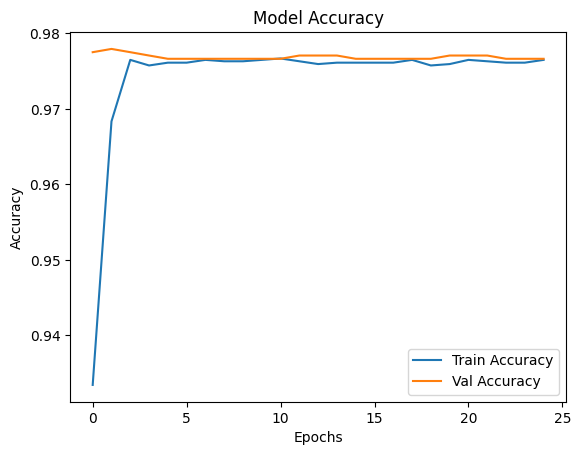

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

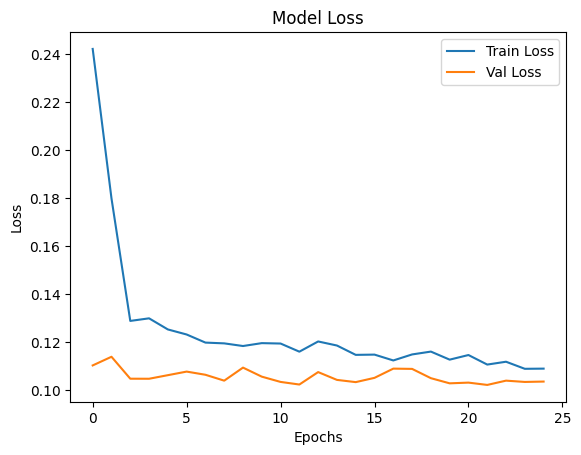

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
X_batch, y_true = next(val_gen)

y_pred = model.predict(X_batch)

y_pred = (y_pred > 0.3).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step


In [ ]:
X_sample, y_sample = next(val_gen)
pred = model.predict(X_sample)

for i in range(5):
    if pred[i] > 0.5:
        print("Anomaly")
    else:
        print("Normal")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Anomaly
Normal
Normal
Normal
Normal


In [ ]:
model.evaluate(val_gen, steps=100)

100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9700 - loss: 0.1268


[0.1268177628517151, 0.9700000286102295]

In [ ]:
X_test, y_test = next(val_gen)

pred = model.predict(X_test)
y_pred = (pred > 0.3).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [ ]:
for i in range(len(y_pred)):
    print("Pred:", "Anomaly" if y_pred[i]==1 else "Normal",
          "| Actual:", y_true[i])

Pred: Normal | Actual: 0
Pred: Normal | Actual: 0
Pred: Normal | Actual: 0
Pred: Normal | Actual: 0
Pred: Normal | Actual: 0
Pred: Anomaly | Actual: 1
Pred: Normal | Actual: 0
Pred: Normal | Actual: 1


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)

print("----- MODEL PERFORMANCE SUMMARY -----\n")

print("NORMAL (Class 0):")
print(f"  Precision : {report['0']['precision']:.2f}")
print(f"  Recall    : {report['0']['recall']:.2f}")
print(f"  F1 Score  : {report['0']['f1-score']:.2f}\n")

print("ANOMALY (Class 1):")
print(f"  Precision : {report['1']['precision']:.2f}")
print(f"  Recall    : {report['1']['recall']:.2f}")
print(f"  F1 Score  : {report['1']['f1-score']:.2f}\n")

print(f"OVERALL ACCURACY: {report['accuracy']:.2f}")

----- MODEL PERFORMANCE SUMMARY -----

NORMAL (Class 0):
  Precision : 1.00
  Recall    : 1.00
  F1 Score  : 1.00

ANOMALY (Class 1):
  Precision : 1.00
  Recall    : 1.00
  F1 Score  : 1.00

OVERALL ACCURACY: 1.00


In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

cap = cv2.VideoCapture("UMN Dataset.mp4")

ret, prev_frame = cap.read()

if not ret:
    print("Error reading video")
else:
    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

    while True:

        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        flow = cv2.calcOpticalFlowFarneback(
            prev_gray, gray,
            None, 0.5, 3, 15, 3, 5, 1.2, 0
        )

        magnitude, _ = cv2.cartToPolar(flow[...,0], flow[...,1])

        motion_map = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
        motion_map = motion_map.astype(np.uint8)

        _, thresh = cv2.threshold(motion_map, 60, 255, cv2.THRESH_BINARY)

        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if np.mean(motion_map) > 20:

            for cnt in contours:
                if cv2.contourArea(cnt) > 2000:
                    x,y,w,h = cv2.boundingRect(cnt)
                    cv2.rectangle(frame,(x,y),(x+w,y+h),(0,0,255),2)

        cv2_imshow(frame)

        prev_gray = gray

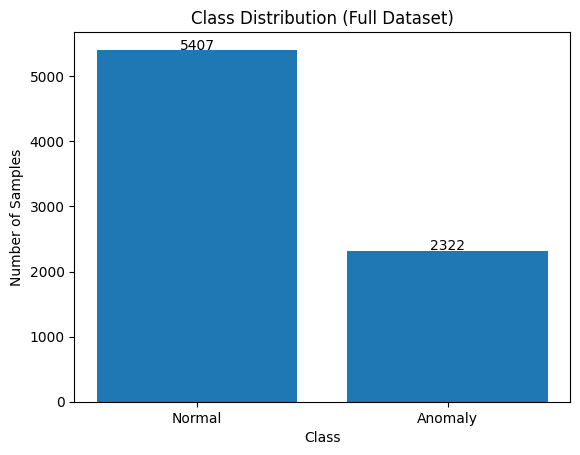

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Count labels (0 = Normal, 1 = Anomaly)
unique, counts = np.unique(labels, return_counts=True)

classes = ['Normal', 'Anomaly']

plt.bar(classes, counts)
plt.title("Class Distribution (Full Dataset)")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()